# Practica 1: Marginacion municipal y reduccion de dimensionalidad

Objetivo:
- Filtrar y consolidar datos por municipio.
- Explorar estructura y completitud de la data.
- Seleccionar variables relevantes por correlacion (no supervisado).
- Definir variables de marginacion por criterio teorico.
- Cruzar ambas selecciones y justificar un set final.
- Proyectar a 2D con PCA y construir un indice de marginacion.

Referencia metodol?gica: `M3P1_Metodos_Reduccion.pdf`.


In [19]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

from ctg_viz.categorization import check_data_completeness_nomnbrecompleto

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', 200)

base = Path('.')
ruta_df = base / "iter_00_cpv2020\conjunto_de_datos\conjunto_de_datos_iter_00CSV20.csv"

# Cargar datos
censo = pd.read_csv(ruta_df, low_memory=False)

# Convertir a num?rico donde aplica
cols_no_numeric = {'NOM_ENT', 'NOM_MUN', 'NOM_LOC', 'LONGITUD', 'LATITUD'}
for col in censo.columns:
    if col not in cols_no_numeric:
        censo[col] = pd.to_numeric(censo[col], errors='coerce')

print('Registros totales:', censo.shape)


Registros totales: (195662, 286)


## 1) Filtrado y consolidaci?n por municipio

Se consolida el nivel municipal sumando localidades: `LOC=0`, `LOC=9998` y `LOC=9999`, como en el notebook de referencia.


In [20]:
# Filtrado base municipal (loc 0 + loc 9998 + loc 9999)
mun_base = censo[
    (censo['ENTIDAD'] > 0) &
    (censo['MUN'] > 0) &
    (censo['LOC'] == 0) #.isin([0, 9998, 9999])) ####
].copy()

cols_no_suma = {
    'ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN',
    'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'TAMLOC'
}
cols_suma = [c for c in censo.columns if c not in cols_no_suma]

mun = (
    mun_base
    .groupby(['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN'], as_index=False)[cols_suma]
    .sum(min_count=1)
)

print(f'Registros usados para consolidar municipio: {mun_base.shape[0]:,}')
print(f'Municipios consolidados: {mun.shape[0]:,}')
print(f'Variables en tabla municipal: {mun.shape[1]:,}')

mun[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'POBTOT', 'TVIVPARHAB']].head()


Registros usados para consolidar municipio: 2,469
Municipios consolidados: 2,469
Variables en tabla municipal: 280


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,POBTOT,TVIVPARHAB
0,1,Aguascalientes,1,Aguascalientes,948990,266778.0
1,1,Aguascalientes,2,Asientos,51536,12542.0
2,1,Aguascalientes,3,Calvillo,58250,15546.0
3,1,Aguascalientes,4,Cosío,17000,3937.0
4,1,Aguascalientes,5,Jesús María,129929,33214.0


## 2) EDA mejorado: estructura y completitud

Incluye:
- Resumen estad?stico de variables clave.
- Faltantes por variable.
- Distribuci?n de poblaci?n total.
- Perfil de completitud con `ctg_viz`.


Completitud por variable (top 20):


,columna,faltantes,completitud %,tipo,std,var,min,max,unicos,categoria
0,ENTIDAD,0,100.0,int64,7.367340,5.427770e+01,1.00,32.00,32,continua
184,P15SEC_COF,0,100.0,float64,13799.026102,1.904131e+08,8.00,188556.00,1846,continua
190,GRAPROES_F,0,100.0,float64,1.540592,2.373425e+00,3.00,14.22,659,continua
189,GRAPROES,0,100.0,float64,1.489042,2.217247e+00,3.40,14.55,633,continua
188,P18YM_PB_M,0,100.0,float64,28965.349351,8.389915e+08,2.00,360239.00,1797,continua
187,P18YM_PB_F,0,100.0,float64,30004.659048,9.002796e+08,7.00,382682.00,1821,continua
186,P18YM_PB,0,100.0,float64,58950.295643,3.475137e+09,11.00,742921.00,2046,continua
185,P15SEC_COM,0,100.0,float64,13063.713782,1.706606e+08,7.00,184815.00,1828,continua
183,P15SEC_CO,0,100.0,float64,26853.975041,7.211360e+08,15.00,373371.00,2100,continua
192,PEA,0,100.0,float64,76860.366446,5.907516e+09,42.00,1051417.00,2287,continua


Completitud por variable (bottom 20):


,columna,faltantes,completitud %,tipo,std,var,min,max,unicos,categoria
73,P_35A39_F,0,100.0,float64,5635.553547,3.175946e+07,2.0,77215.0,1397,continua
72,P_35A39,0,100.0,float64,10990.825701,1.207982e+08,3.0,155043.0,1695,continua
86,P_55A59_M,0,100.0,float64,3323.665046,1.104675e+07,1.0,45370.0,1131,continua
87,P_60A64,0,100.0,float64,6090.219704,3.709078e+07,0.0,87752.0,1426,continua
88,P_60A64_F,0,100.0,float64,3304.237285,1.091798e+07,0.0,48146.0,1093,continua
89,P_60A64_M,0,100.0,float64,2788.931779,7.778140e+06,0.0,39606.0,1044,continua
90,P_65A69,0,100.0,float64,4493.654896,2.019293e+07,2.0,64935.0,1315,continua
91,P_65A69_F,0,100.0,float64,2456.686284,6.035308e+06,2.0,35877.0,991,continua
92,P_65A69_M,0,100.0,float64,2039.126247,4.158036e+06,0.0,29058.0,951,continua
93,P_70A74,0,100.0,float64,3280.123464,1.075921e+07,3.0,46866.0,1164,continua


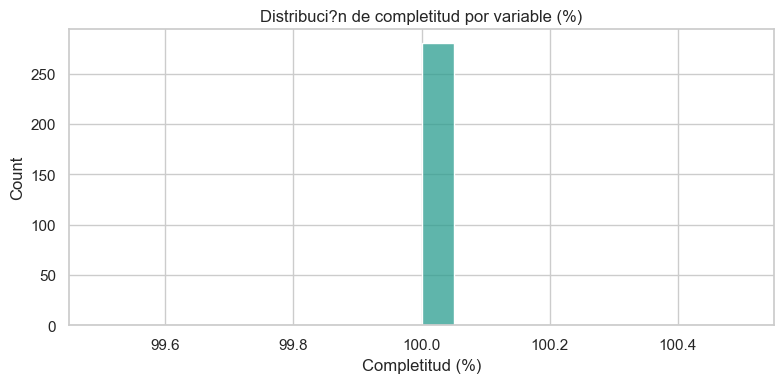

Resumen de completitud:


,completitud %
count,280.0
mean,100.0
std,0.0
min,100.0
25%,100.0
50%,100.0
75%,100.0
max,100.0


In [21]:
# EDA: completitud global y distribuci?n de faltantes

comp = check_data_completeness_nomnbrecompleto(mun)
comp = comp.sort_values('completitud %', ascending=False)

print('Completitud por variable (top 20):')
display(comp.head(20))

print('Completitud por variable (bottom 20):')
display(comp.tail(20))

# Distribuci?n de completitud
plt.figure(figsize=(8, 4))
sns.histplot(comp['completitud %'], bins=20, color='#2a9d8f')
plt.title('Distribuci?n de completitud por variable (%)')
plt.xlabel('Completitud (%)')
plt.tight_layout()
plt.show()

# Resumen r?pido de faltantes
print('Resumen de completitud:')
display(comp['completitud %'].describe().to_frame('completitud %'))


## 3) Selecci?n de variables por correlaci?n (no supervisado)

Se seleccionan variables con alta variabilidad y baja redundancia.


Top variables por score combinado (variabilidad):


PDER_IMSS      0.880435
PNACOE         0.804348
VPH_TINACO     0.783816
PDER_ISTE      0.649758
PRO_CRIEVA     0.634058
VPH_BICI       0.580918
PRESOE15       0.564010
PDER_SEGP      0.549517
PAFIL_IPRIV    0.525362
PHOG_IND       0.498792
POB_AFRO       0.495169
PDER_ISTEE     0.444444
PAFIL_OTRAI    0.442029
PAFIL_PDOM     0.426932
P3HLINHE       0.417271
VIVPAR_DES     0.380435
POTRAS_REL     0.367150
P_80A84_F      0.299517
VPH_NDEAED     0.287440
VPH_1CUART     0.277778
VPH_SINLTC     0.234300
VIVPAR_UT      0.210145
PDER_IMSSB     0.185990
VPH_LETR       0.167874
VPH_NODREN     0.157005
VPH_AGUAFV     0.154589
VPH_PISOTI     0.143720
VPH_SINTIC     0.111111
P12A14NOA      0.105072
P8A14AN_F      0.069444
dtype: float64

Variables seleccionadas (correlacin):
['PDER_IMSS', 'PNACOE', 'VPH_TINACO', 'PDER_ISTE', 'PRO_CRIEVA', 'VPH_BICI', 'PRESOE15', 'PDER_SEGP', 'PAFIL_IPRIV', 'PHOG_IND', 'POB_AFRO', 'PDER_ISTEE', 'PAFIL_OTRAI', 'PAFIL_PDOM', 'P3HLINHE', 'VIVPAR_DES', 'POTRAS_REL', 'P_80A84_F', 'VPH_NDEAED', 'VPH_1CUART', 'VPH_SINLTC', 'VIVPAR_UT', 'PDER_IMSSB', 'VPH_LETR', 'VPH_NODREN', 'VPH_AGUAFV', 'VPH_PISOTI', 'VPH_SINTIC', 'P12A14NOA', 'P8A14AN_F']


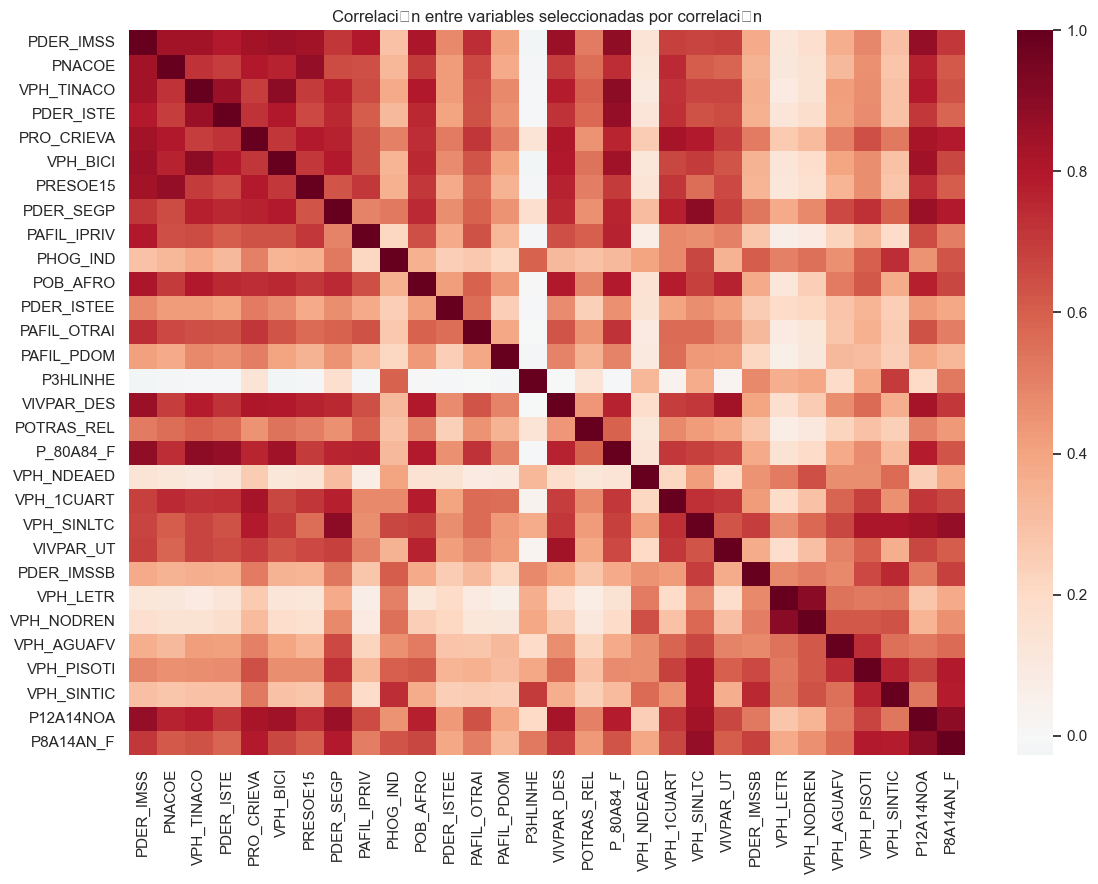

In [22]:
# Seleccin no supervisada por variabilidad + baja redundancia
# Quita IDs y conserva solo numricos
id_cols = ['ENTIDAD', 'MUN', 'LOC', 'NOM_ENT', 'NOM_MUN', 'NOM_LOC']
X = mun.drop(columns=[c for c in id_cols if c in mun.columns], errors='ignore')
X = X.select_dtypes(include='number').copy()

# Elimina constantes
X = X.loc[:, X.nunique(dropna=True) > 1]

# Score combinado (std, IQR, CV)
std = X.std()
iqr = X.quantile(0.75) - X.quantile(0.25)
cv = std / (X.mean().abs() + 1e-9)

score = pd.concat([std, iqr, cv], axis=1)
score.columns = ['std', 'iqr', 'cv']
score_rank = score.rank(pct=True).mean(axis=1).sort_values(ascending=False)

# Seleccin con umbral de correlacin
umbral_corr = 0.90
corr = X.corr().abs()
selected = []

for var in score_rank.index:
    if not selected:
        selected.append(var)
        continue
    if (corr.loc[var, selected] <= umbral_corr).all():
        selected.append(var)
    if len(selected) >= 30:
        break

ranking_final = score_rank.loc[selected].sort_values(ascending=False)
top_vars_corr = selected
X_sel = X[top_vars_corr].copy()

print('Top variables por score combinado (variabilidad):')
display(ranking_final)

print('Variables seleccionadas (correlacin):')
print(top_vars_corr)

# Matriz de correlacin para variables seleccionadas
plt.figure(figsize=(12, 9))
corr_sel = X_sel.corr()
sns.heatmap(corr_sel, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlacin entre variables seleccionadas por correlacin')
plt.tight_layout()
plt.show()


## 4) Variables de marginaci?n por definici?n

Se construyen tasas de carencias seg?n definiciones de marginaci?n (educaci?n, salud y vivienda).


Municipios con informaci?n completa para modelado: 2,469


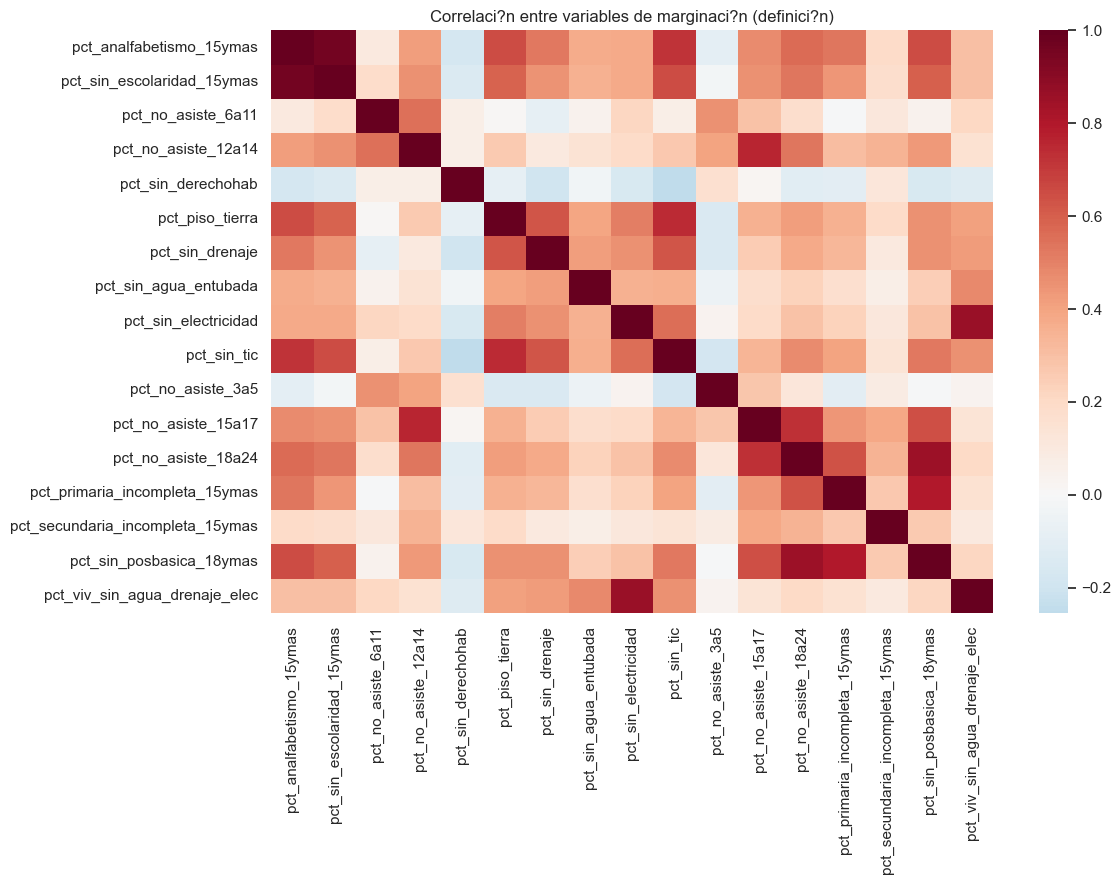

In [23]:
analisis_mun = mun.copy()

def agregar_tasa(df, numerador, denominador, nombre, sentido='directo'):
    tasa = 100 * df[numerador] / df[denominador]
    if sentido == 'inverso':
        tasa = 100 - tasa
    df[nombre] = tasa

# Set final de variables artificiales
especificaciones = [
    ('pct_analfabetismo_15ymas', 'P15YM_AN', 'P_15YMAS', 'directo'),
    ('pct_sin_escolaridad_15ymas', 'P15YM_SE', 'P_15YMAS', 'directo'),
    ('pct_no_asiste_6a11', 'P6A11_NOA', 'P_6A11', 'directo'),
    ('pct_no_asiste_12a14', 'P12A14NOA', 'P_12A14', 'directo'),
    ('pct_sin_derechohab', 'PSINDER', 'POBTOT', 'directo'),
    ('pct_piso_tierra', 'VPH_PISOTI', 'TVIVPARHAB', 'directo'),
    ('pct_sin_drenaje', 'VPH_NODREN', 'TVIVPARHAB', 'directo'),
    ('pct_sin_agua_entubada', 'VPH_AGUAFV', 'TVIVPARHAB', 'directo'),
    ('pct_sin_electricidad', 'VPH_S_ELEC', 'TVIVPARHAB', 'directo'),
    ('pct_sin_tic', 'VPH_SINTIC', 'TVIVPARHAB', 'directo'),

    # Bloque candidato
    ('pct_no_asiste_3a5', 'P3A5_NOA', 'P_3A5', 'directo'),
    ('pct_no_asiste_15a17', 'P15A17A', 'P_15A17', 'inverso'),
    ('pct_no_asiste_18a24', 'P18A24A', 'P_18A24', 'inverso'),
    ('pct_primaria_incompleta_15ymas', 'P15PRI_IN', 'P_15YMAS', 'directo'),
    ('pct_secundaria_incompleta_15ymas', 'P15SEC_IN', 'P_15YMAS', 'directo'),
    ('pct_sin_posbasica_18ymas', 'P18YM_PB', 'P_18YMAS', 'inverso'),
    ('pct_viv_sin_agua_drenaje_elec', 'VPH_NDEAED', 'TVIVPARHAB', 'directo'),
]

for nombre, num, den, sentido in especificaciones:
    agregar_tasa(analisis_mun, num, den, nombre, sentido=sentido)

vars_marginacion = [x[0] for x in especificaciones]

modelo_df = (
    analisis_mun[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN'] + vars_marginacion]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print(f'Municipios con informaci?n completa para modelado: {modelo_df.shape[0]:,}')

plt.figure(figsize=(12, 9))
corr_marg = modelo_df[vars_marginacion].corr()
sns.heatmap(corr_marg, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlaci?n entre variables de marginaci?n (definici?n)')
plt.tight_layout()
plt.show()


## 5) Cruce: variables por correlaci?n vs. variables por definici?n

Se conserva el bloque de definici?n con respaldo emp?rico: variables de marginaci?n que muestran correlaci?n alta con el set no supervisado.


In [24]:
# Cruce y justificaci?n: intersecci?n + refuerzo por correlaci?n
# Intersecci?n estricta entre definici?n y correlaci?n
vars_cruce = [v for v in vars_marginacion if v in top_vars_corr]

# Asegurar que no sea menor al set por definici?n
# Si la intersecci?n es menor, se conserva el set por definici?n completo.
if len(vars_cruce) < len(vars_marginacion):
    vars_cruce = vars_marginacion.copy()

# Quitar redundancia alta dentro del set final
if len(vars_cruce) > 1:
    corr_cruce = modelo_df[vars_cruce].corr().abs()
    upper = corr_cruce.where(np.triu(np.ones(corr_cruce.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if (upper[c] > 0.90).any()]
    vars_cruce = [v for v in vars_cruce if v not in to_drop]

print('Variables finales para PCA (definici?n + correlaci?n):')
print(vars_cruce)


Variables finales para PCA (definici?n + correlaci?n):
['pct_analfabetismo_15ymas', 'pct_no_asiste_6a11', 'pct_no_asiste_12a14', 'pct_sin_derechohab', 'pct_piso_tierra', 'pct_sin_drenaje', 'pct_sin_agua_entubada', 'pct_sin_electricidad', 'pct_sin_tic', 'pct_no_asiste_3a5', 'pct_no_asiste_15a17', 'pct_no_asiste_18a24', 'pct_primaria_incompleta_15ymas', 'pct_secundaria_incompleta_15ymas', 'pct_sin_posbasica_18ymas', 'pct_viv_sin_agua_drenaje_elec']


### Cruce y justificaci?n (modelo robusto)

El cruce entre la selecci?n por definici?n y la selecci?n por correlaci?n garantiza un modelo robusto porque combina dos criterios complementarios.
Primero, se conserva el bloque definido por teor?a de marginaci?n (educaci?n, salud, vivienda y acceso a servicios), lo que asegura relevancia contextual y capacidad explicativa.
Segundo, se verifica que dichas variables est?n respaldadas por evidencia emp?rica (alta relaci?n con variables con mayor variabilidad), lo que aumenta la estabilidad estad?stica del modelo.

Adem?s, se elimina redundancia excesiva (|r| > 0.90) dentro del conjunto final, lo que favorece la multicolinealidad estructurada requerida por PCA sin introducir duplicidad artificial.
En conjunto, el cruce produce un set defendible tanto anal?ticamente como conceptualmente, reduciendo ruido, evitando sobreajuste y mejorando la interpretabilidad del ?ndice resultante.


Varianza explicada por PC1: 0.3714
Varianza explicada por PC2: 0.1543
Varianza explicada acumulada (2 componentes): 0.5257
Cargas PCA (ordenadas por contribuci?n absoluta en PC1):


,PC1,PC2
pct_sin_posbasica_18ymas,0.335,-0.093
pct_analfabetismo_15ymas,0.332,0.064
pct_no_asiste_18a24,0.325,-0.197
pct_sin_tic,0.323,0.215
pct_piso_tierra,0.306,0.197
pct_no_asiste_15a17,0.283,-0.345
pct_primaria_incompleta_15ymas,0.273,-0.054
pct_sin_drenaje,0.273,0.269
pct_sin_electricidad,0.255,0.196
pct_no_asiste_12a14,0.235,-0.415


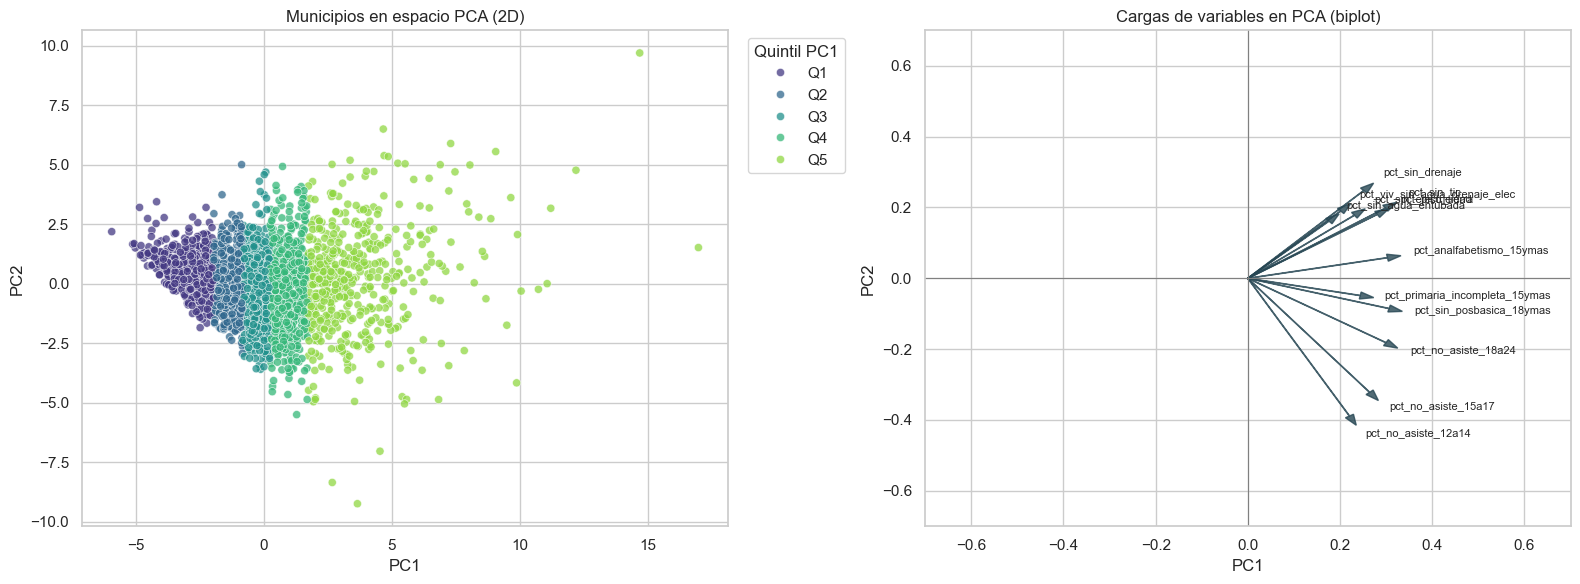

In [25]:
X = modelo_df[vars_cruce].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Alinear el signo de PC1 para que valores altos representen mayor carencia
promedio_carencias = X.mean(axis=1)
if np.corrcoef(X_pca[:, 0], promedio_carencias)[0, 1] < 0:
    X_pca[:, 0] = -X_pca[:, 0]
    pca.components_[0, :] *= -1

pca_df = modelo_df[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN']].copy()
pca_df['PC1'] = X_pca[:, 0]
pca_df['PC2'] = X_pca[:, 1]
pca_df['quintil_pc1'] = pd.qcut(pca_df['PC1'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {var_exp[0]:.4f}')
print(f'Varianza explicada por PC2: {var_exp[1]:.4f}')
print(f'Varianza explicada acumulada (2 componentes): {var_exp.sum():.4f}')

loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_cruce,
    columns=['PC1', 'PC2']
)

print('Cargas PCA (ordenadas por contribuci?n absoluta en PC1):')
display(loadings.sort_values('PC1', key=np.abs, ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='quintil_pc1',
    palette='viridis',
    alpha=0.75,
    s=35,
    ax=axes[0]
)
axes[0].set_title('Municipios en espacio PCA (2D)')
axes[0].legend(title='Quintil PC1', bbox_to_anchor=(1.02, 1), loc='upper left')

axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axvline(0, color='gray', lw=0.8)
vars_biplot = loadings['PC1'].abs().sort_values(ascending=False).head(12).index
for var in vars_biplot:
    x = loadings.loc[var, 'PC1']
    y = loadings.loc[var, 'PC2']
    axes[1].arrow(0, 0, x, y, color='#264653', alpha=0.8, head_width=0.02, length_includes_head=True)
    axes[1].text(x * 1.08, y * 1.08, var, fontsize=8)

axes[1].set_xlim(-0.7, 0.7)
axes[1].set_ylim(-0.7, 0.7)
axes[1].set_title('Cargas de variables en PCA (biplot)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()


## 7) ?ndice de marginaci?n por municipio (basado en PCA)

Se usa PC1 como ?ndice sint?tico y se escala a 0-100, siguiendo la idea del ?ndice de criminalidad del notebook de PCA.


Top 10 municipios con mayor marginaci?n (?ndice 0-100):


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,indice_marginacion
213,8,Chihuahua,8,Batopilas de Manuel Gómez Morín,100.000000
302,10,Durango,14,Mezquital,89.992956
946,18,Nayarit,9,Del Nayar,79.125436
599,14,Jalisco,61,Mezquitic,74.833417
103,7,Chiapas,22,Chalchihuitán,74.216838
451,12,Guerrero,78,Cochoapa el Grande,72.728509
212,8,Chihuahua,7,Balleza,69.777575
270,8,Chihuahua,65,Urique,69.169907
217,8,Chihuahua,12,Carichí,69.012344
1179,20,Oaxaca,171,San José Tenango,68.021448


Top 10 municipios con menor marginaci?n (?ndice 0-100):


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,indice_marginacion
285,9,Ciudad de México,14,Benito Juárez,0.000000
287,9,Ciudad de México,16,Miguel Hidalgo,3.578788
1358,20,Oaxaca,350,San Sebastián Tutla,3.829811
274,9,Ciudad de México,3,Coyoacán,4.019978
1255,20,Oaxaca,247,Capulálpam de Méndez,4.742957
2065,29,Tlaxcala,33,Tlaxcala,4.890014
1697,21,Puebla,119,San Andrés Cholula,4.985060
505,13,Hidalgo,51,Mineral de la Reforma,5.170664
717,15,México,54,Metepec,5.207990
683,15,México,20,Coacalco de Berriozábal,5.463792


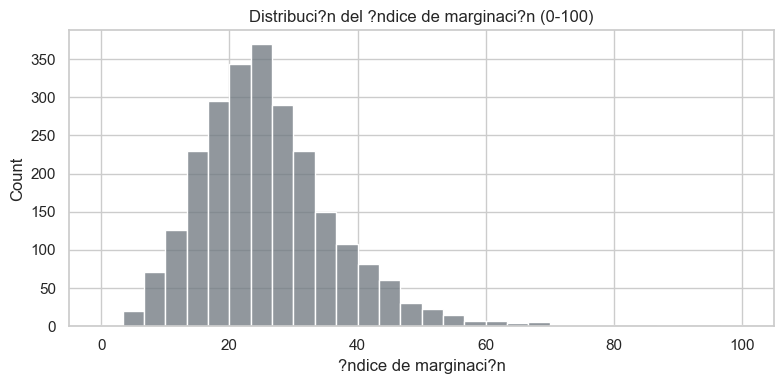

In [26]:
# Indice de marginaci?n basado en PC1
indice = pca_df[['PC1']].copy()

scaler_mm = MinMaxScaler(feature_range=(0, 100))
indice['indice_marginacion'] = scaler_mm.fit_transform(indice[['PC1']])

indice_final = pca_df[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN']].copy()
indice_final['indice_marginacion'] = indice['indice_marginacion'].values

print('Top 10 municipios con mayor marginaci?n (?ndice 0-100):')
display(indice_final.sort_values('indice_marginacion', ascending=False).head(10))

print('Top 10 municipios con menor marginaci?n (?ndice 0-100):')
display(indice_final.sort_values('indice_marginacion', ascending=True).head(10))

plt.figure(figsize=(8, 4))
sns.histplot(indice_final['indice_marginacion'], bins=30, color='#6c757d')
plt.title('Distribuci?n del ?ndice de marginaci?n (0-100)')
plt.xlabel('?ndice de marginaci?n')
plt.tight_layout()
plt.show()


## Hallazgos y notas

- El filtrado municipal reduce la granularidad y mejora la estabilidad de los indicadores.
- La selecci?n por correlaci?n reduce redundancia y prioriza variables con mayor variaci?n.
- El cruce entre definici?n te?rica y evidencia emp?rica produce un set m?s defendible.
- PCA 2D facilita interpretaci?n visual, aunque no captura toda la varianza.
- El ?ndice de marginaci?n (PC1) sintetiza carencias y permite ranking municipal.
